<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

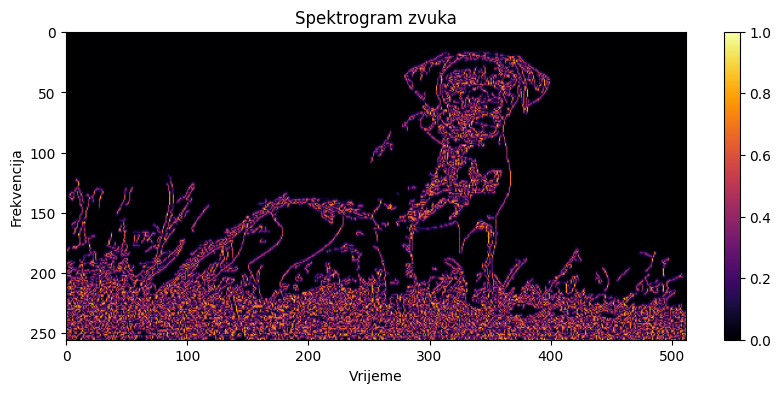

In [27]:

!pip install librosa soundfile opencv-python -q

import numpy as np
import cv2
import librosa
import soundfile as sf
import matplotlib.pyplot as plt
from google.colab import files
import IPython.display as ipd


img = cv2.imread("Data/dog.jpg", cv2.IMREAD_GRAYSCALE)

img = cv2.Canny(img, 50, 150)

img = cv2.resize(img, (512, 256))

img = img.astype(np.float32) / 255.0

audio = librosa.griffinlim(img, n_iter=128, hop_length=256, n_fft=510)

audio = audio / np.abs(audio).max()


ipd.display(ipd.Audio(audio, rate=22050))

sf.write("zvuk.wav", audio, 22050)
files.download("zvuk.wav")


D = np.abs(librosa.stft(audio, n_fft=510, hop_length=256))

plt.figure(figsize=(10, 4))
plt.imshow(D / D.max(), origin="upper", aspect="auto", cmap="inferno")
plt.title("Spektrogram zvuka")
plt.xlabel("Vrijeme")
plt.ylabel("Frekvencija")
plt.colorbar()
plt.show()
